<a href="https://colab.research.google.com/github/Paulo123213/MineriaDatos/blob/main/prueba1mineria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('tl-calculated-delta-table.csv')

In [2]:
df_clean = pd.read_csv('tl-calculated-delta-table.csv')

In [4]:
df_clean = df_clean.drop(columns=['vs', 'raw_eff', 'adjusted_eff', 'verified'])

In [5]:
print(df_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 13 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   raw_app       float64
 6   adjusted_app  float64
 7   tr            float64
 8   glicko        float64
 9   rd            int64  
 10  gamesplayed   int64  
 11  gameswon      int64  
 12  deltadate     object 
dtypes: float64(6), int64(3), object(4)
memory usage: 811.1+ MB
None


In [6]:
df_clean.head(10)

,id,username,tlrank,apm,pps,raw_app,adjusted_app,tr,glicko,rd,gamesplayed,gameswon,deltadate
0,5e484c3eadfab42c76f0af36,vince,x,139.63,3.44,0.676502,0.452287,24546.0,2553.0,85,31,26,2020-04-08 17:42:00
1,5e3f6ebe3dacc16dbc4dd6aa,doremy,x,116.71,2.79,0.697192,0.465930,24266.0,2419.0,71,100,86,2020-04-08 17:42:00
2,5e40825a4be6907ad7eab03d,sm999,u,128.92,3.32,0.647189,0.432719,24239.0,2409.0,72,72,64,2020-04-08 17:42:00
3,5e3d58e92445dd5207770ca5,wumbo,u,93.24,2.37,0.655696,0.438045,24213.0,2401.0,75,74,67,2020-04-08 17:42:00
4,5e4f0ad196a8426ec442746e,qmk,u,121.82,2.92,0.695320,0.464754,24137.0,2376.0,76,44,39,2020-04-08 17:42:00
5,5e40a2b74be6907ad7eab292,cheep,u,109.59,2.88,0.634201,0.423902,24012.0,2345.0,95,20,14,2020-04-08 17:42:00
6,5e697bbf77aba60f95fb38da,firestorm,u,119.78,2.94,0.679025,0.453900,23948.0,2320.0,70,64,49,2020-04-08 17:42:00
7,5e381f4c456244768a097502,zack101155,u,104.13,2.51,0.691434,0.462049,23638.0,2251.0,79,38,35,2020-04-08 17:42:00
8,5e436daf368a5d2489fbf848,star,u,107.18,2.74,0.651946,0.435760,23570.0,2243.0,99,24,24,2020-04-08 17:42:00
9,5e4db4eff5d51a6eb7ec0bb6,zerot,u,115.67,3.05,0.632077,0.422605,23563.0,2238.0,87,25,22,2020-04-08 17:42:00


In [7]:
df_clean.isna().sum()

,0
id,0
username,0
tlrank,0
apm,0
pps,0
raw_app,0
adjusted_app,0
tr,0
glicko,0
rd,0


In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8177602 entries, 0 to 8177601
Data columns (total 17 columns):
 #   Column        Dtype  
---  ------        -----  
 0   id            object 
 1   username      object 
 2   tlrank        object 
 3   apm           float64
 4   pps           float64
 5   vs            float64
 6   raw_eff       float64
 7   adjusted_eff  float64
 8   raw_app       float64
 9   adjusted_app  float64
 10  tr            float64
 11  glicko        float64
 12  rd            int64  
 13  gamesplayed   int64  
 14  gameswon      int64  
 15  verified      float64
 16  deltadate     object 
dtypes: float64(10), int64(3), object(4)
memory usage: 1.0+ GB
None


In [9]:
rank_mapping = {
    'X': 17,
    'U': 16,
    'SS': 15,
    'S+': 14,
    'S': 13,
    'S-': 12,
    'A+': 11,
    'A': 10,
    'A-': 9,
    'B+': 8,
    'B': 7,
    'B-': 6,
    'C+': 5,
    'C': 4,
    'C-': 3,
    'D+': 2,
    'D': 1,
    'z': 0
    }
df_clean['rank_num'] = df_clean['tlrank'].str.lower().map(rank_mapping)

In [13]:
cols_numericas = ['apm', 'pps', 'raw_app', 'adjusted_app', 'rank_num']
for col in cols_numericas:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

In [15]:
df_clean = df_clean[cols_numericas].dropna()

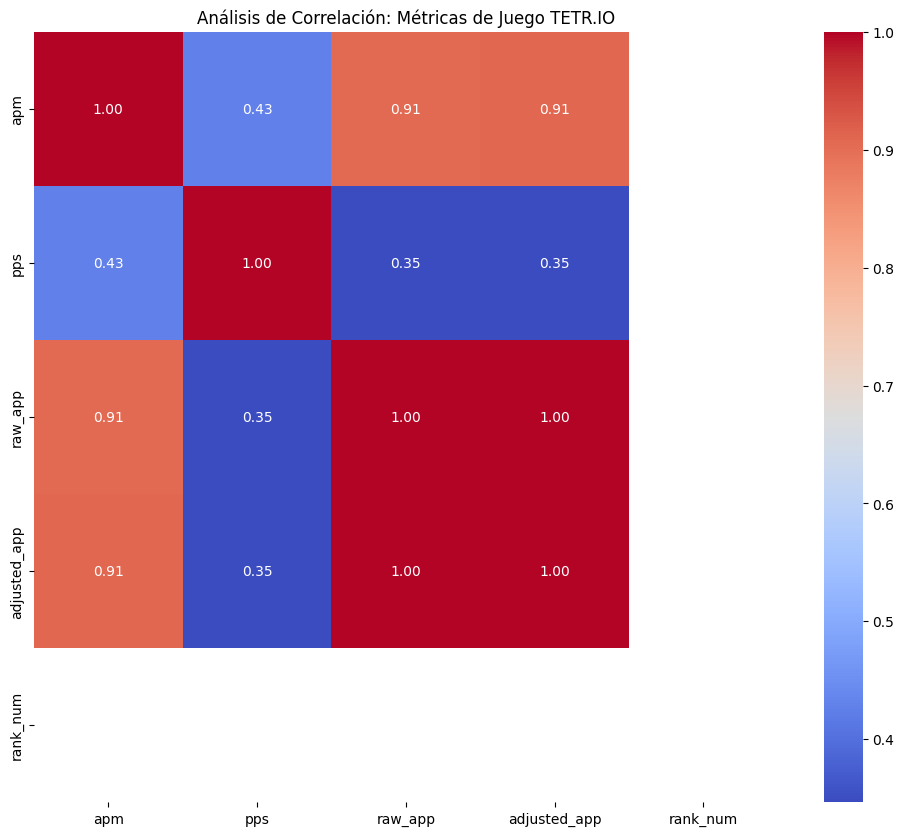

In [16]:
corr_matrix = df_clean.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")


plt.title('Análisis de Correlación: Métricas de Juego TETR.IO')
plt.show()

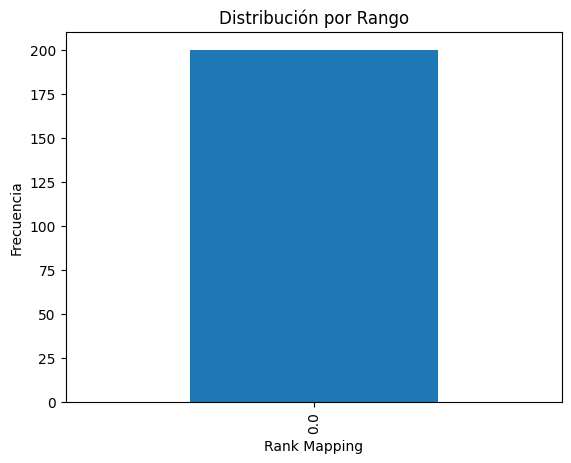

In [21]:
plot = df_clean['rank_num'].value_counts().sort_index().plot(kind='bar', title='Distribución por Rango')
plot.set_ylabel('Frecuencia')
plot.set_xlabel('Rank Mapping')
plt.show()